In [3]:
import os
import tarfile
import urllib.request
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import KFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras import layers, models, regularizers, initializers

print("TensorFlow version:", tf.__version__)
print("TensorFlow imported successfully!")

TensorFlow version: 2.20.0
TensorFlow imported successfully!


In [4]:
IMG_SIZE = (224, 224)
NUM_CLASSES = 37
BASE_BATCH_SIZE = 16
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("Image size:", IMG_SIZE)
print("Number of classes:", NUM_CLASSES)
print("Base batch size:", BASE_BATCH_SIZE)

Image size: (224, 224)
Number of classes: 37
Base batch size: 16


In [5]:
DATASET_DIR = os.path.join(os.getcwd(), "oxford_iiit_pet")
IMAGES_DIR = os.path.join(DATASET_DIR, "images")
ANNOTATIONS_DIR = os.path.join(DATASET_DIR, "annotations")

os.makedirs(DATASET_DIR, exist_ok=True)

BASE_HOST = "www.robots.ox.ac.uk"
BASE_PATH = "/~vgg/data/pets/data"

images_url = f"https://{BASE_HOST}{BASE_PATH}/images.tar.gz"
annotations_url = f"https://{BASE_HOST}{BASE_PATH}/annotations.tar.gz"

images_tar = os.path.join(DATASET_DIR, "images.tar.gz")
annotations_tar = os.path.join(DATASET_DIR, "annotations.tar.gz")

if not os.path.exists(IMAGES_DIR):
    print("Downloading images...")
    urllib.request.urlretrieve(images_url, images_tar)

    print("Extracting images...")
    with tarfile.open(images_tar, "r:gz") as tar:
        tar.extractall(DATASET_DIR)

if not os.path.exists(ANNOTATIONS_DIR):
    print("Downloading annotations...")
    urllib.request.urlretrieve(annotations_url, annotations_tar)

    print("Extracting annotations...")
    with tarfile.open(annotations_tar, "r:gz") as tar:
        tar.extractall(DATASET_DIR)

print("Dataset downloaded successfully!")
print("Images directory:", IMAGES_DIR)
print("Annotations directory:", ANNOTATIONS_DIR)

Extracting images...


/tmp/ipykernel_518/2395319368.py:22: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATASET_DIR)


Extracting annotations...


/tmp/ipykernel_518/2395319368.py:30: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATASET_DIR)


Dataset downloaded successfully!
Images directory: /content/oxford_iiit_pet/images
Annotations directory: /content/oxford_iiit_pet/annotations


In [6]:
TRAINVAL_FILE = os.path.join(ANNOTATIONS_DIR, "trainval.txt")
TEST_FILE = os.path.join(ANNOTATIONS_DIR, "test.txt")

def read_annotation_file(file_path):
    file_paths = []
    labels = []

    with open(file_path, "r") as file:
        for line in file:
            line = line.strip()

            if not line or line.startswith("#"):
                continue

            parts = line.split()

            image_name = parts[0]
            class_id = int(parts[1]) - 1

            image_path = os.path.join(
                IMAGES_DIR,
                image_name + ".jpg"
            )

            if os.path.exists(image_path):
                file_paths.append(image_path)
                labels.append(class_id)

    return np.array(file_paths), np.array(labels, dtype=np.int32)


trainval_paths, trainval_labels = read_annotation_file(TRAINVAL_FILE)

test_paths, test_labels = read_annotation_file(TEST_FILE)

print("Train/Validation samples:", len(trainval_paths))
print("Test samples:", len(test_paths))
print("Number of classes:", len(np.unique(trainval_labels)))

Train/Validation samples: 3680
Test samples: 3669
Number of classes: 37


In [7]:
class_names = [None] * NUM_CLASSES

with open(TRAINVAL_FILE, "r") as file:
    for line in file:
        line = line.strip()

        if not line or line.startswith("#"):
            continue

        parts = line.split()

        image_name = parts[0]
        class_id = int(parts[1]) - 1

        breed_name = "_".join(
            image_name.split("_")[:-1]
        )

        if class_names[class_id] is None:
            class_names[class_id] = breed_name


print("Number of classes:", len(class_names))

for i, name in enumerate(class_names[:10]):
    print(i, ":", name)

Number of classes: 37
0 : Abyssinian
1 : american_bulldog
2 : american_pit_bull_terrier
3 : basset_hound
4 : beagle
5 : Bengal
6 : Birman
7 : Bombay
8 : boxer
9 : British_Shorthair


In [8]:
def preprocess_image(path, label):
    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image = tf.keras.applications.mobilenet_v2.preprocess_input(
        image
    )

    return image, label

In [9]:
def create_dataset(
    paths,
    labels,
    batch_size=BASE_BATCH_SIZE,
    shuffle=False
):
    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(batch_size)

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset


print("Dataset function created successfully!")

Dataset function created successfully!


In [10]:
rng = np.random.default_rng(SEED)

indices = np.arange(len(trainval_paths))

rng.shuffle(indices)

VAL_SIZE = int(
    0.20 * len(trainval_paths)
)

val_indices = indices[:VAL_SIZE]

train_indices = indices[VAL_SIZE:]


train_paths = trainval_paths[train_indices]
train_labels = trainval_labels[train_indices]

val_paths = trainval_paths[val_indices]
val_labels = trainval_labels[val_indices]


print("Training samples:", len(train_paths))
print("Validation samples:", len(val_paths))
print("Test samples:", len(test_paths))

Training samples: 2944
Validation samples: 736
Test samples: 3669


In [11]:
train_base = create_dataset(
    train_paths,
    train_labels,
    batch_size=BASE_BATCH_SIZE,
    shuffle=True
)

val_base = create_dataset(
    val_paths,
    val_labels,
    batch_size=BASE_BATCH_SIZE,
    shuffle=False
)

test_base = create_dataset(
    test_paths,
    test_labels,
    batch_size=BASE_BATCH_SIZE,
    shuffle=False
)

print("Training, validation and test datasets are ready!")

Training, validation and test datasets are ready!


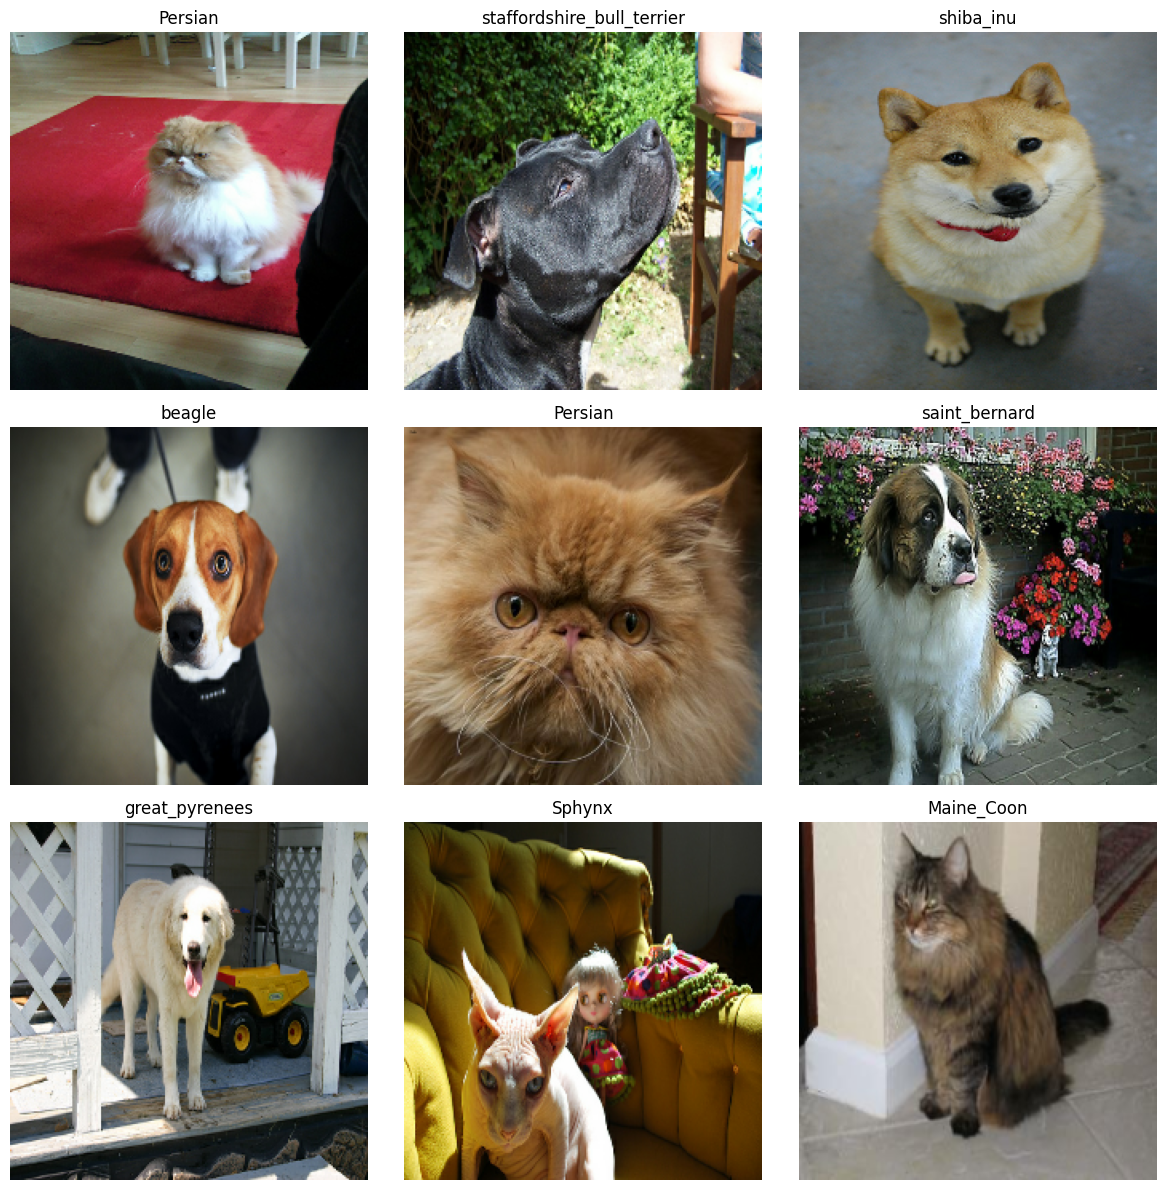

In [12]:
display_dataset = tf.data.Dataset.from_tensor_slices(
    (train_paths[:9], train_labels[:9])
)

display_dataset = display_dataset.map(
    preprocess_image
).batch(9)


images, labels = next(
    iter(display_dataset)
)

plt.figure(figsize=(12, 12))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    image = (
        images[i].numpy() + 1
    ) / 2

    image = np.clip(
        image,
        0,
        1
    )

    plt.imshow(image)

    plt.title(
        class_names[
            labels[i].numpy()
        ]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
def create_base_model(
    trainable=False
):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(
            IMG_SIZE[0],
            IMG_SIZE[1],
            3
        ),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = trainable

    return base_model

In [14]:
def create_model(
    initializer="he_normal",
    dropout_rate=0.0,
    l2_strength=0.0,
    use_batch_norm=False,
    hidden_units=256,
    base_trainable=False
):
    base_model = create_base_model(
        trainable=base_trainable
    )

    inputs = layers.Input(
        shape=(
            IMG_SIZE[0],
            IMG_SIZE[1],
            3
        )
    )

    x = base_model(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(
        x
    )

    x = layers.Dense(
        hidden_units,
        activation=None,
        kernel_initializer=initializer,
        kernel_regularizer=regularizers.l2(
            l2_strength
        )
    )(x)

    if use_batch_norm:
        x = layers.BatchNormalization()(x)

    x = layers.Activation(
        "relu"
    )(x)

    if dropout_rate > 0:
        x = layers.Dropout(
            dropout_rate
        )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        kernel_initializer=initializer,
        kernel_regularizer=regularizers.l2(
            l2_strength
        )
    )(x)

    model = models.Model(
        inputs,
        outputs
    )

    return model

In [15]:
def compile_model(
    model,
    optimizer_name="adam",
    learning_rate=0.001
):
    if optimizer_name.lower() == "sgd":

        optimizer = tf.keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    elif optimizer_name.lower() == "momentum":

        optimizer = tf.keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=0.9
        )

    elif optimizer_name.lower() == "rmsprop":

        optimizer = tf.keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    else:

        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [16]:
def plot_history(
    history,
    title="Training History"
):
    epochs = range(
        1,
        len(history.history["loss"]) + 1
    )

    plt.figure(figsize=(14, 5))

    # Training and Validation Loss
    plt.subplot(1, 2, 1)

    plt.plot(
        epochs,
        history.history["loss"],
        label="Training Loss"
    )

    plt.plot(
        epochs,
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(
        title + " - Loss"
    )

    plt.legend()
    plt.grid(True)

    # Training and Validation Accuracy
    plt.subplot(1, 2, 2)

    plt.plot(
        epochs,
        np.array(
            history.history["accuracy"]
        ) * 100,
        label="Training Accuracy"
    )

    plt.plot(
        epochs,
        np.array(
            history.history["val_accuracy"]
        ) * 100,
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(
        title + " - Accuracy"
    )

    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [17]:
initializers_to_test = {
    "Zero": initializers.Zeros(),

    "Random": initializers.RandomNormal(
        mean=0.0,
        stddev=0.05,
        seed=SEED
    ),

    "Xavier": initializers.GlorotUniform(
        seed=SEED
    ),

    "He": initializers.HeNormal(
        seed=SEED
    )
}

print(
    list(
        initializers_to_test.keys()
    )
)

['Zero', 'Random', 'Xavier', 'He']


In [18]:
EPOCHS_INIT = 8

initialization_histories = {}

for name, initializer in initializers_to_test.items():

    print("\n" + "=" * 60)
    print(
        "Training with",
        name,
        "Initialization"
    )
    print("=" * 60)

    tf.keras.backend.clear_session()

    model = create_model(
        initializer=initializer,
        dropout_rate=0.0,
        l2_strength=0.0,
        use_batch_norm=False,
        hidden_units=256,
        base_trainable=False
    )

    model = compile_model(
        model,
        optimizer_name="adam",
        learning_rate=0.001
    )

    history = model.fit(
        train_base,
        validation_data=val_base,
        epochs=EPOCHS_INIT,
        verbose=1
    )

    initialization_histories[name] = history


Training with Zero Initialization
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 32s 76ms/step - accuracy: 0.0228 - loss: 3.6115 - val_accuracy: 0.0136 - val_loss: 3.6122
Epoch 2/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.0265 - loss: 3.6112 - val_accuracy: 0.0136 - val_loss: 3.6130
Epoch 3/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.0279 - loss: 3.6110 - val_accuracy: 0.0136 - val_loss: 3.6140
Epoch 4/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.0217 - loss: 3.6108 - val_accuracy: 0.0136 - val_loss: 3.6148
Epoch 5/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.0275 - loss: 3.6107 - val_accuracy: 0.0136 - val_loss: 3.6156
Epoch 6/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.0306 - loss: 3.6106 - val_accuracy: 0.0136 - val_loss: 3.6163
Epoch 7/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.0306 - loss: 3.6106 - val_accuracy: 0.0136 - val_loss: 3.6169
Epoch 8/8
184/184

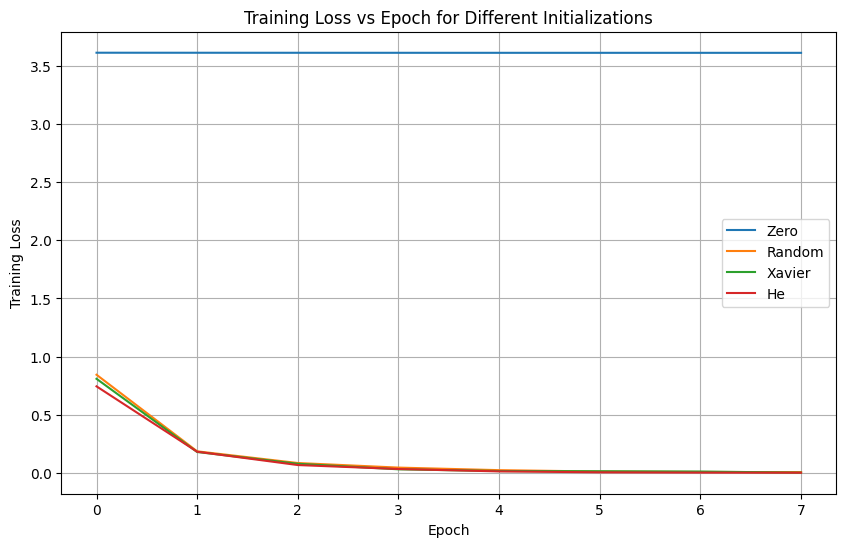

In [19]:
plt.figure(figsize=(10, 6))

for name, history in initialization_histories.items():

    plt.plot(
        history.history["loss"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title(
    "Training Loss vs Epoch for Different Initializations"
)

plt.legend()
plt.grid(True)

plt.show()

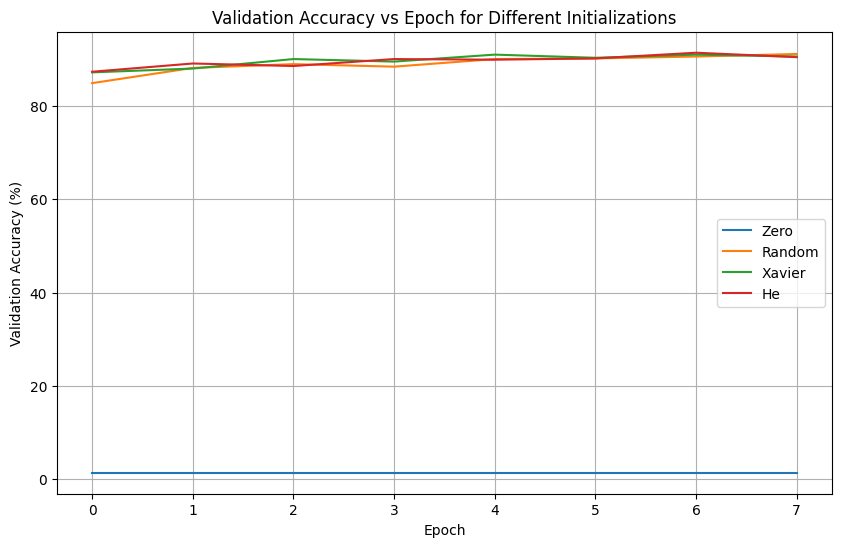

In [20]:
plt.figure(figsize=(10, 6))

for name, history in initialization_histories.items():

    plt.plot(
        np.array(
            history.history["val_accuracy"]
        ) * 100,
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Validation Accuracy vs Epoch for Different Initializations"
)

plt.legend()
plt.grid(True)

plt.show()

In [21]:
initialization_results = []

for name, history in initialization_histories.items():

    initialization_results.append(
        {
            "Initialization": name,

            "Final Training Loss":
                history.history["loss"][-1],

            "Final Validation Loss":
                history.history["val_loss"][-1],

            "Best Validation Accuracy (%)":
                max(
                    history.history["val_accuracy"]
                ) * 100
        }
    )


initialization_results_df = pd.DataFrame(
    initialization_results
)

initialization_results_df

,Initialization,Final Training Loss,Final Validation Loss,Best Validation Accuracy (%)
0,Zero,3.610479,3.617400,1.358696
1,Random,0.008358,0.313519,91.168481
2,Xavier,0.003732,0.286812,91.032606
3,He,0.003192,0.295229,91.440219


In [22]:
regularization_configs = {
    "No Regularization": {
        "dropout_rate": 0.0,
        "l2_strength": 0.0,
        "use_batch_norm": False
    },

    "L2 Regularization": {
        "dropout_rate": 0.0,
        "l2_strength": 1e-4,
        "use_batch_norm": False
    },

    "Dropout": {
        "dropout_rate": 0.5,
        "l2_strength": 0.0,
        "use_batch_norm": False
    },

    "Batch Normalization": {
        "dropout_rate": 0.0,
        "l2_strength": 0.0,
        "use_batch_norm": True
    }
}

In [23]:
EPOCHS_REG = 8

regularization_histories = {}

for name, config in regularization_configs.items():

    print("\n" + "=" * 60)
    print("Training:", name)
    print("=" * 60)

    tf.keras.backend.clear_session()

    model = create_model(
        initializer="he_normal",

        dropout_rate=config[
            "dropout_rate"
        ],

        l2_strength=config[
            "l2_strength"
        ],

        use_batch_norm=config[
            "use_batch_norm"
        ],

        hidden_units=256,
        base_trainable=False
    )

    model = compile_model(
        model,
        optimizer_name="adam",
        learning_rate=0.001
    )

    history = model.fit(
        train_base,
        validation_data=val_base,
        epochs=EPOCHS_REG,
        verbose=1
    )

    regularization_histories[name] = history


Training: No Regularization
Epoch 1/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 24s 82ms/step - accuracy: 0.7738 - loss: 0.7941 - val_accuracy: 0.8533 - val_loss: 0.4789
Epoch 2/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.9436 - loss: 0.1729 - val_accuracy: 0.8845 - val_loss: 0.3449
Epoch 3/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.9820 - loss: 0.0667 - val_accuracy: 0.8872 - val_loss: 0.3857
Epoch 4/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.9905 - loss: 0.0369 - val_accuracy: 0.8832 - val_loss: 0.3580
Epoch 5/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.9963 - loss: 0.0185 - val_accuracy: 0.8927 - val_loss: 0.3933
Epoch 6/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.9983 - loss: 0.0093 - val_accuracy: 0.9076 - val_loss: 0.2791
Epoch 7/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 1.0000 - loss: 0.0051 - val_accuracy: 0.9144 - val_loss: 0.2884
Epoch 8/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 1.0000 

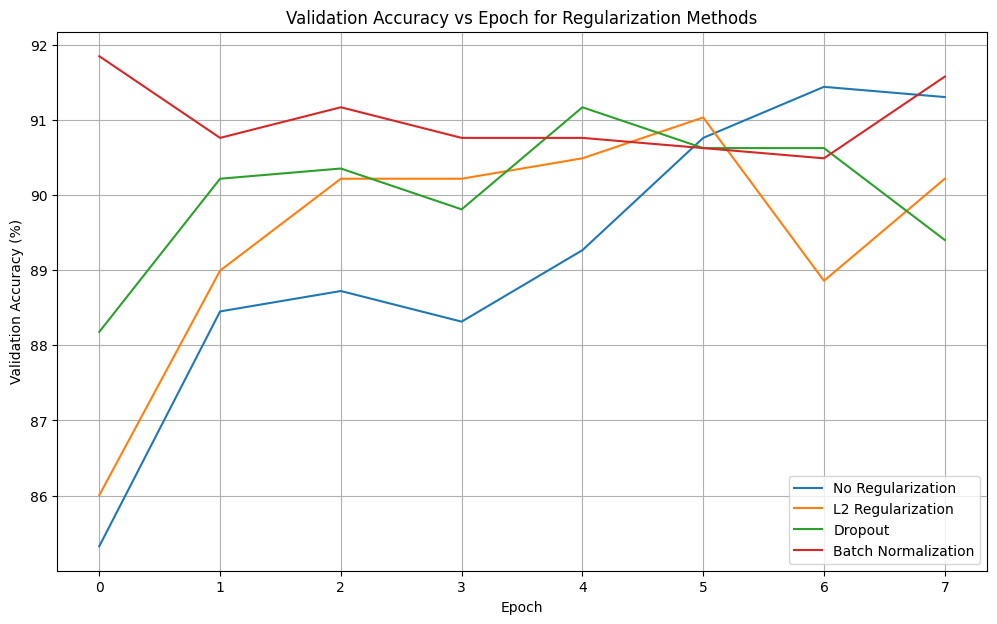

In [24]:
plt.figure(figsize=(12, 7))

for name, history in regularization_histories.items():

    plt.plot(
        np.array(
            history.history["val_accuracy"]
        ) * 100,
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Validation Accuracy vs Epoch for Regularization Methods"
)

plt.legend()
plt.grid(True)

plt.show()

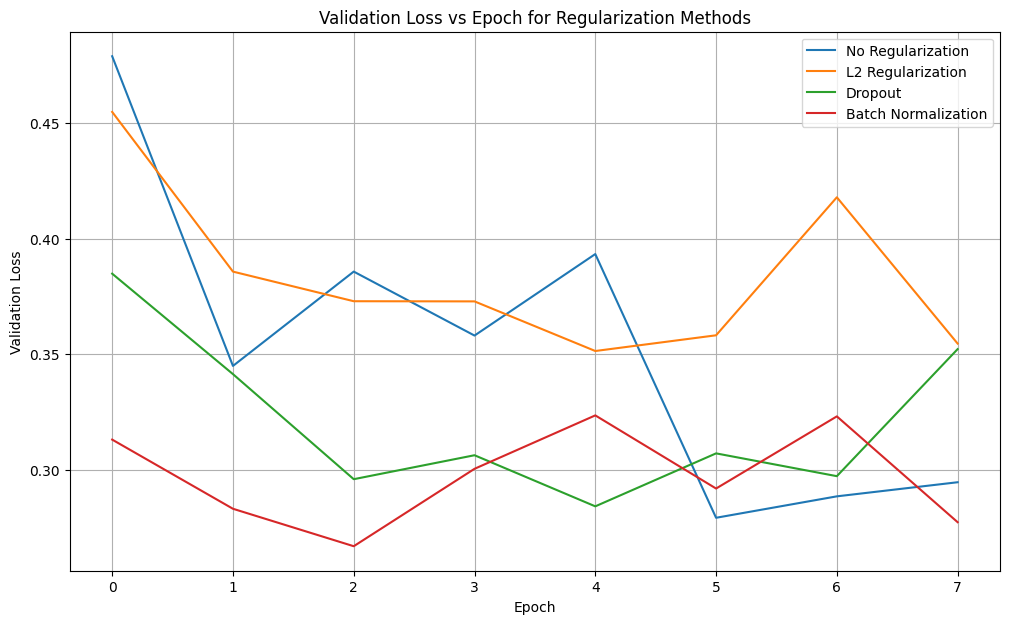

In [25]:
plt.figure(figsize=(12, 7))

for name, history in regularization_histories.items():

    plt.plot(
        history.history["val_loss"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.title(
    "Validation Loss vs Epoch for Regularization Methods"
)

plt.legend()
plt.grid(True)

plt.show()

In [26]:
x = np.array(
    [2.0, 4.0, 6.0, 8.0]
)

epsilon = 1e-7

mu = np.mean(x)

variance = np.var(x)

x_hat = (
    x - mu
) / np.sqrt(
    variance + epsilon
)

gamma = 1.0
beta = 0.0

y = (
    gamma * x_hat
) + beta


print("Input x:")
print(x)

print("\nBatch mean (mu):")
print(mu)

print("\nBatch variance:")
print(variance)

print("\nNormalized values:")
print(x_hat)

print("\nFinal output:")
print(y)

Input x:
[2. 4. 6. 8.]

Batch mean (mu):
5.0

Batch variance:
5.0

Normalized values:
[-1.34164077 -0.44721359  0.44721359  1.34164077]

Final output:
[-1.34164077 -0.44721359  0.44721359  1.34164077]


In [27]:
optimizers_to_test = {
    "SGD": {
        "name": "sgd",
        "learning_rate": 0.01
    },

    "Momentum": {
        "name": "momentum",
        "learning_rate": 0.01
    },

    "RMSprop": {
        "name": "rmsprop",
        "learning_rate": 0.001
    },

    "Adam": {
        "name": "adam",
        "learning_rate": 0.001
    }
}

In [28]:
EPOCHS_OPT = 8

optimizer_histories = {}
optimizer_training_time = {}

for display_name, config in optimizers_to_test.items():

    print("\n" + "=" * 60)
    print(
        "Training with",
        display_name
    )
    print("=" * 60)

    tf.keras.backend.clear_session()

    model = create_model(
        initializer="he_normal",
        dropout_rate=0.2,
        l2_strength=0.0,
        use_batch_norm=True,
        hidden_units=256,
        base_trainable=False
    )

    model = compile_model(
        model,
        optimizer_name=config["name"],
        learning_rate=config[
            "learning_rate"
        ]
    )

    start_time = time.time()

    history = model.fit(
        train_base,
        validation_data=val_base,
        epochs=EPOCHS_OPT,
        verbose=1
    )

    end_time = time.time()

    optimizer_histories[
        display_name
    ] = history

    optimizer_training_time[
        display_name
    ] = end_time - start_time


Training with SGD
Epoch 1/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 24s 81ms/step - accuracy: 0.4681 - loss: 2.1783 - val_accuracy: 0.8302 - val_loss: 0.9340
Epoch 2/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.8349 - loss: 0.8150 - val_accuracy: 0.8736 - val_loss: 0.5414
Epoch 3/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.8804 - loss: 0.5460 - val_accuracy: 0.8832 - val_loss: 0.4372
Epoch 4/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.9096 - loss: 0.4264 - val_accuracy: 0.8818 - val_loss: 0.3932
Epoch 5/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.9266 - loss: 0.3466 - val_accuracy: 0.8927 - val_loss: 0.3596
Epoch 6/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.9331 - loss: 0.3022 - val_accuracy: 0.8940 - val_loss: 0.3441
Epoch 7/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.9436 - loss: 0.2665 - val_accuracy: 0.8967 - val_loss: 0.3329
Epoch 8/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.9555 - loss: 

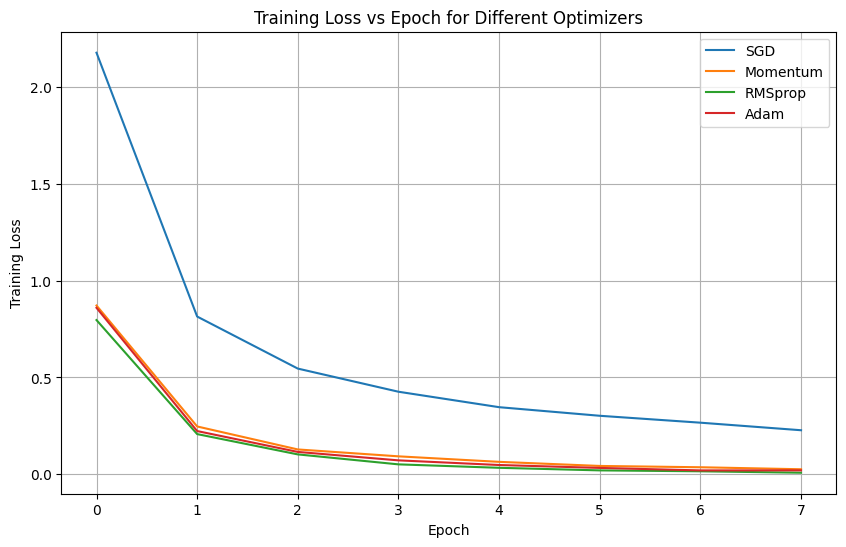

In [29]:
plt.figure(figsize=(10, 6))

for name, history in optimizer_histories.items():

    plt.plot(
        history.history["loss"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title(
    "Training Loss vs Epoch for Different Optimizers"
)

plt.legend()
plt.grid(True)

plt.show()

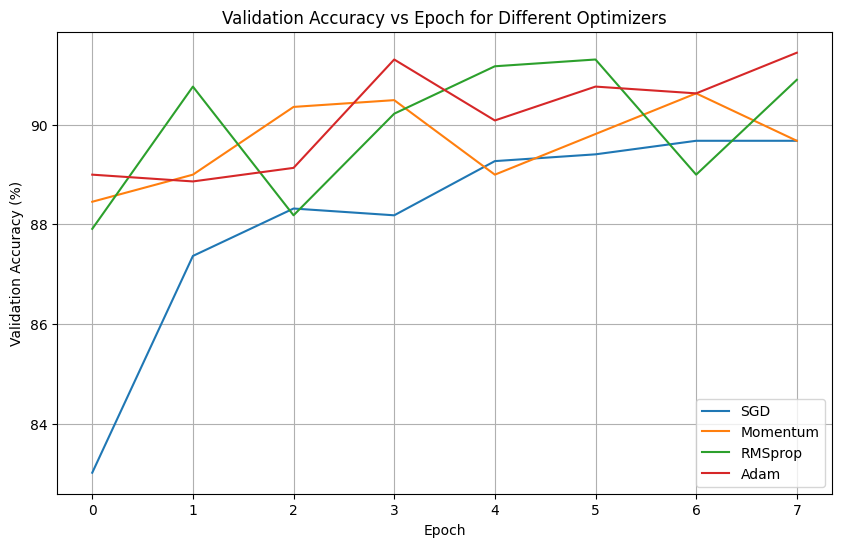

In [30]:
plt.figure(figsize=(10, 6))

for name, history in optimizer_histories.items():

    plt.plot(
        np.array(
            history.history["val_accuracy"]
        ) * 100,
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Validation Accuracy vs Epoch for Different Optimizers"
)

plt.legend()
plt.grid(True)

plt.show()

In [31]:
optimizer_results = []

for name, history in optimizer_histories.items():

    final_loss = history.history["loss"][-1]

    best_val_accuracy = max(
        history.history["val_accuracy"]
    ) * 100

    best_epoch = (
        np.argmax(
            history.history["val_accuracy"]
        ) + 1
    )

    optimizer_results.append(
        {
            "Optimizer": name,

            "Final Loss":
                final_loss,

            "Best Val Accuracy (%)":
                best_val_accuracy,

            "Epoch to Best":
                best_epoch,

            "Training Time (s)":
                optimizer_training_time[name]
        }
    )


optimizer_results_df = pd.DataFrame(
    optimizer_results
)

optimizer_results_df

,Optimizer,Final Loss,Best Val Accuracy (%),Epoch to Best,Training Time (s)
0,SGD,0.227425,89.673913,7,94.427206
1,Momentum,0.025805,90.625000,7,92.234090
2,RMSprop,0.007888,91.304350,6,97.013428
3,Adam,0.020070,91.440219,8,89.078370


In [32]:
learning_rates = [
    0.001,
    0.0001
]

learning_rate_histories = {}

for learning_rate in learning_rates:

    print("\n" + "=" * 60)
    print(
        "Learning Rate:",
        learning_rate
    )
    print("=" * 60)

    tf.keras.backend.clear_session()

    model = create_model(
        initializer="he_normal",
        dropout_rate=0.2,
        l2_strength=0.0,
        use_batch_norm=True,
        hidden_units=256,
        base_trainable=False
    )

    model = compile_model(
        model,
        optimizer_name="adam",
        learning_rate=learning_rate
    )

    history = model.fit(
        train_base,
        validation_data=val_base,
        epochs=6,
        verbose=1
    )

    learning_rate_histories[
        learning_rate
    ] = history


Learning Rate: 0.001
Epoch 1/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.7785 - loss: 0.8490 - val_accuracy: 0.8954 - val_loss: 0.3257
Epoch 2/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.9443 - loss: 0.2076 - val_accuracy: 0.8967 - val_loss: 0.3020
Epoch 3/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.9749 - loss: 0.1161 - val_accuracy: 0.9049 - val_loss: 0.2859
Epoch 4/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.9851 - loss: 0.0749 - val_accuracy: 0.8995 - val_loss: 0.2995
Epoch 5/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.9881 - loss: 0.0513 - val_accuracy: 0.9090 - val_loss: 0.3116
Epoch 6/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.9973 - loss: 0.0298 - val_accuracy: 0.8981 - val_loss: 0.3161

Learning Rate: 0.0001
Epoch 1/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 28s 99ms/step - accuracy: 0.3325 - loss: 2.6839 - val_accuracy: 0.7296 - val_loss: 1.3911
Epoch 2/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step 

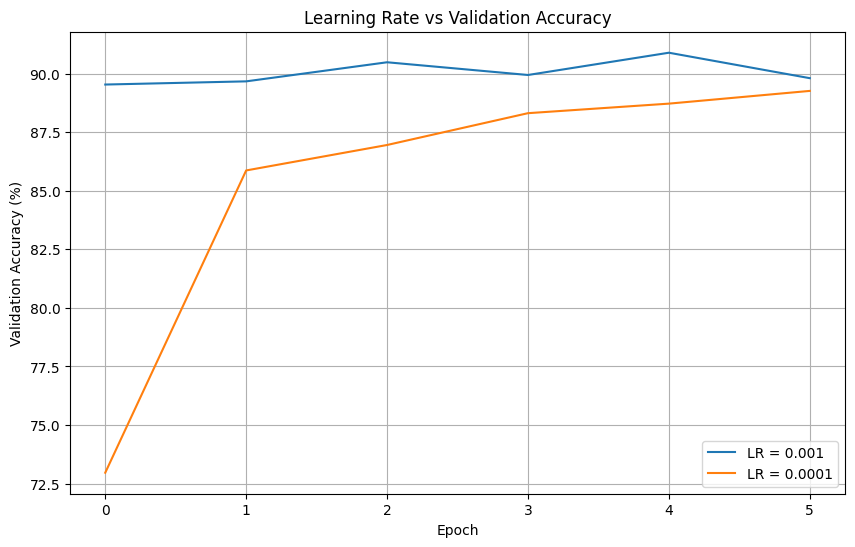

In [33]:
plt.figure(figsize=(10, 6))

for learning_rate, history in learning_rate_histories.items():

    plt.plot(
        np.array(
            history.history["val_accuracy"]
        ) * 100,

        label=f"LR = {learning_rate}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Learning Rate vs Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()

In [34]:
batch_sizes = [
    16,
    32,
    64
]

batch_size_histories = {}

for batch_size in batch_sizes:

    print("\n" + "=" * 60)
    print(
        "Batch Size:",
        batch_size
    )
    print("=" * 60)

    tf.keras.backend.clear_session()

    train_ds = create_dataset(
        train_paths,
        train_labels,
        batch_size=batch_size,
        shuffle=True
    )

    val_ds = create_dataset(
        val_paths,
        val_labels,
        batch_size=batch_size,
        shuffle=False
    )

    model = create_model(
        initializer="he_normal",
        dropout_rate=0.2,
        l2_strength=0.0,
        use_batch_norm=True,
        hidden_units=256,
        base_trainable=False
    )

    model = compile_model(
        model,
        optimizer_name="adam",
        learning_rate=0.0001
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=6,
        verbose=1
    )

    batch_size_histories[
        batch_size
    ] = history


Batch Size: 16
Epoch 1/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 28s 97ms/step - accuracy: 0.3689 - loss: 2.5166 - val_accuracy: 0.7609 - val_loss: 1.2897
Epoch 2/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.7942 - loss: 1.0524 - val_accuracy: 0.8641 - val_loss: 0.6734
Epoch 3/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.8679 - loss: 0.6780 - val_accuracy: 0.8872 - val_loss: 0.5019
Epoch 4/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.9049 - loss: 0.5032 - val_accuracy: 0.8927 - val_loss: 0.4252
Epoch 5/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.9287 - loss: 0.3951 - val_accuracy: 0.9090 - val_loss: 0.3820
Epoch 6/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.9389 - loss: 0.3322 - val_accuracy: 0.9144 - val_loss: 0.3497

Batch Size: 32
Epoch 1/6
92/92 ━━━━━━━━━━━━━━━━━━━━ 36s 189ms/step - accuracy: 0.2962 - loss: 2.8202 - val_accuracy: 0.6671 - val_loss: 1.8457
Epoch 2/6
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.7330

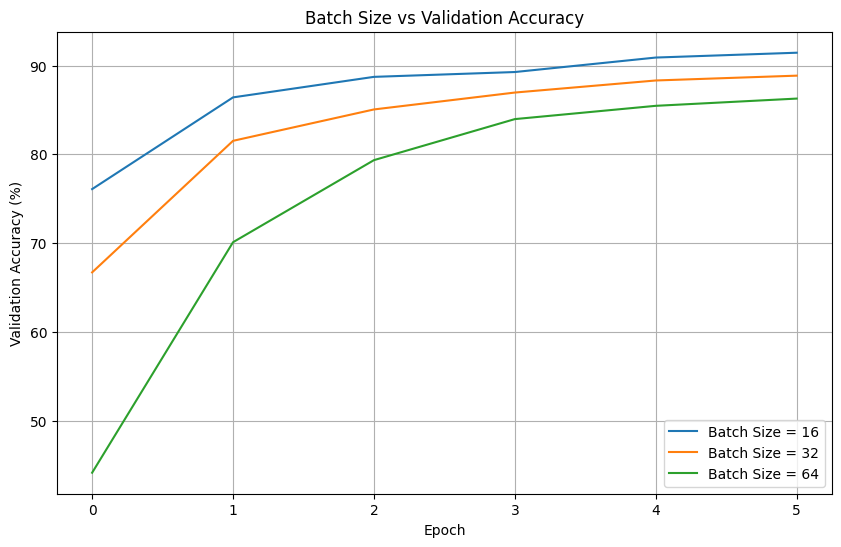

In [35]:
plt.figure(figsize=(10, 6))

for batch_size, history in batch_size_histories.items():

    plt.plot(
        np.array(
            history.history["val_accuracy"]
        ) * 100,

        label=f"Batch Size = {batch_size}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Batch Size vs Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()

In [36]:
dropout_rates = [
    0.2,
    0.5
]

dropout_histories = {}

for dropout_rate in dropout_rates:

    print("\n" + "=" * 60)
    print(
        "Dropout:",
        dropout_rate
    )
    print("=" * 60)

    tf.keras.backend.clear_session()

    model = create_model(
        initializer="he_normal",
        dropout_rate=dropout_rate,
        l2_strength=0.0,
        use_batch_norm=True,
        hidden_units=256,
        base_trainable=False
    )

    model = compile_model(
        model,
        optimizer_name="adam",
        learning_rate=0.0001
    )

    history = model.fit(
        train_base,
        validation_data=val_base,
        epochs=6,
        verbose=1
    )

    dropout_histories[
        dropout_rate
    ] = history


Dropout: 0.2
Epoch 1/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 24s 75ms/step - accuracy: 0.3842 - loss: 2.4583 - val_accuracy: 0.7785 - val_loss: 1.2124
Epoch 2/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.7809 - loss: 1.0199 - val_accuracy: 0.8533 - val_loss: 0.6592
Epoch 3/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.8713 - loss: 0.6610 - val_accuracy: 0.8791 - val_loss: 0.5012
Epoch 4/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.8961 - loss: 0.5026 - val_accuracy: 0.8845 - val_loss: 0.4276
Epoch 5/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.9270 - loss: 0.3942 - val_accuracy: 0.8899 - val_loss: 0.3815
Epoch 6/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.9378 - loss: 0.3149 - val_accuracy: 0.8954 - val_loss: 0.3575

Dropout: 0.5
Epoch 1/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 23s 71ms/step - accuracy: 0.2018 - loss: 3.1464 - val_accuracy: 0.6984 - val_loss: 1.6191
Epoch 2/6
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.605

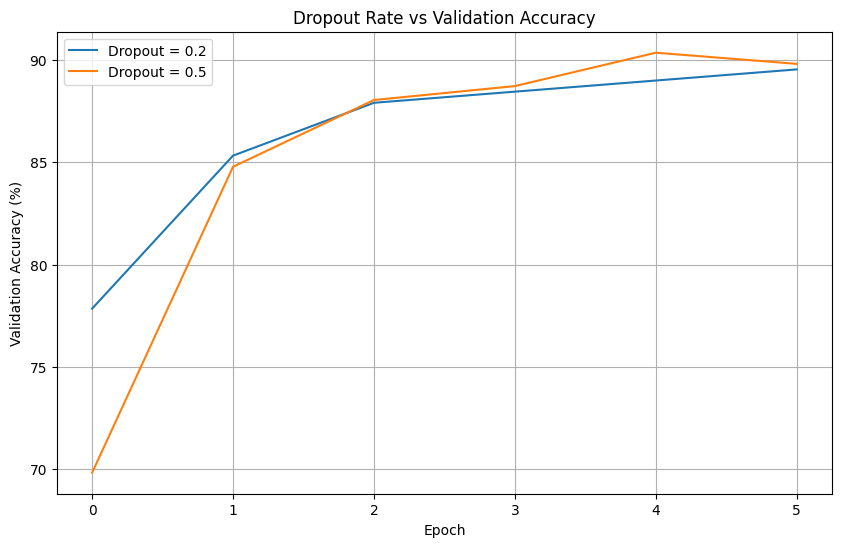

In [37]:
plt.figure(figsize=(10, 6))

for dropout_rate, history in dropout_histories.items():

    plt.plot(
        np.array(
            history.history["val_accuracy"]
        ) * 100,

        label=f"Dropout = {dropout_rate}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Dropout Rate vs Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()

In [38]:
EPOCHS_FEATURE_EXTRACTION = 8

tf.keras.backend.clear_session()

feature_model = create_model(
    initializer="he_normal",
    dropout_rate=0.2,
    l2_strength=0.0,
    use_batch_norm=True,
    hidden_units=256,
    base_trainable=False
)

feature_model = compile_model(
    feature_model,
    optimizer_name="adam",
    learning_rate=0.0001
)

feature_history = feature_model.fit(
    train_base,
    validation_data=val_base,
    epochs=EPOCHS_FEATURE_EXTRACTION,
    verbose=1
)

Epoch 1/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step - accuracy: 0.3876 - loss: 2.4697 - val_accuracy: 0.7391 - val_loss: 1.2906
Epoch 2/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.7897 - loss: 1.0290 - val_accuracy: 0.8397 - val_loss: 0.7010
Epoch 3/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.8618 - loss: 0.6737 - val_accuracy: 0.8832 - val_loss: 0.5245
Epoch 4/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.9035 - loss: 0.4960 - val_accuracy: 0.8899 - val_loss: 0.4465
Epoch 5/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.9273 - loss: 0.3912 - val_accuracy: 0.8954 - val_loss: 0.3926
Epoch 6/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.9443 - loss: 0.3177 - val_accuracy: 0.8940 - val_loss: 0.3695
Epoch 7/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.9511 - loss: 0.2720 - val_accuracy: 0.8995 - val_loss: 0.3464
Epoch 8/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.9586 - loss: 0.2404 - val_accuracy:

In [39]:
feature_model.layers[1].trainable = True

for layer in feature_model.layers[1].layers[:-20]:
    layer.trainable = False


feature_model = compile_model(
    feature_model,
    optimizer_name="adam",
    learning_rate=1e-5
)


EPOCHS_FINE_TUNING = 5

fine_tune_history = feature_model.fit(
    train_base,
    validation_data=val_base,
    epochs=EPOCHS_FINE_TUNING,
    verbose=1
)

Epoch 1/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 29s 76ms/step - accuracy: 0.9052 - loss: 0.4465 - val_accuracy: 0.8859 - val_loss: 0.3350
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 29s 55ms/step - accuracy: 0.9246 - loss: 0.3842 - val_accuracy: 0.8886 - val_loss: 0.3282
Epoch 3/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.9276 - loss: 0.3482 - val_accuracy: 0.8967 - val_loss: 0.3160
Epoch 4/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.9440 - loss: 0.3008 - val_accuracy: 0.8913 - val_loss: 0.3099
Epoch 5/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.9521 - loss: 0.2718 - val_accuracy: 0.8995 - val_loss: 0.3055


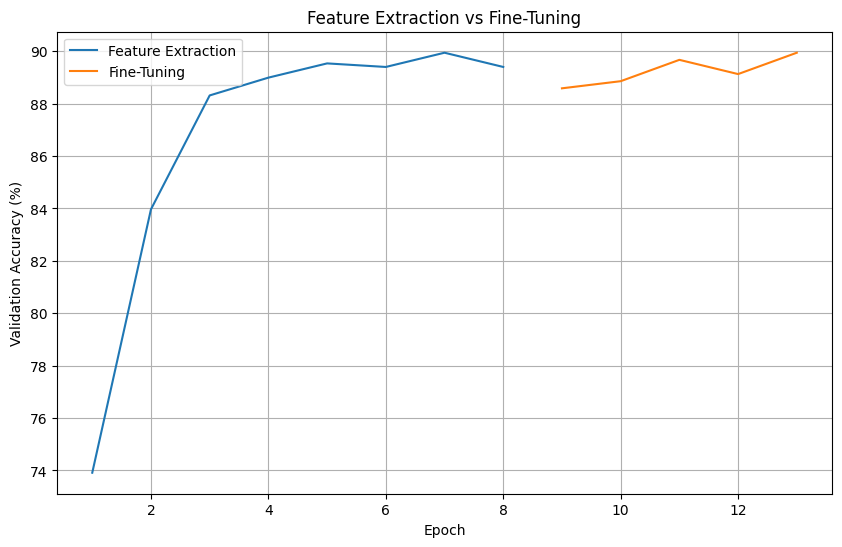

In [40]:
feature_val_accuracy = np.array(
    feature_history.history[
        "val_accuracy"
    ]
) * 100

fine_tune_val_accuracy = np.array(
    fine_tune_history.history[
        "val_accuracy"
    ]
) * 100


plt.figure(figsize=(10, 6))

plt.plot(
    range(
        1,
        len(feature_val_accuracy) + 1
    ),

    feature_val_accuracy,

    label="Feature Extraction"
)

plt.plot(
    range(
        len(feature_val_accuracy) + 1,

        len(feature_val_accuracy)
        + len(fine_tune_val_accuracy)
        + 1
    ),

    fine_tune_val_accuracy,

    label="Fine-Tuning"
)


plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Feature Extraction vs Fine-Tuning"
)

plt.legend()
plt.grid(True)

plt.show()

In [2]:
# ============================================================
# CROSS-VALIDATION CONFIGURATIONS: C1, C2, C3 AND C4
# ============================================================

cv_configurations = {

    # C1: He + BatchNorm + Adam
    "C1": {
        "initializer": "he_normal",
        "dropout_rate": 0.20,
        "l2_strength": 0.0,
        "use_batch_norm": True,
        "optimizer": "adam",
        "learning_rate": 0.0001,
        "batch_size": 16
    },

    # C2: Higher dropout
    "C2": {
        "initializer": "he_normal",
        "dropout_rate": 0.50,
        "l2_strength": 0.0,
        "use_batch_norm": True,
        "optimizer": "adam",
        "learning_rate": 0.0001,
        "batch_size": 16
    },

    # C3: L2 regularization
    "C3": {
        "initializer": "he_normal",
        "dropout_rate": 0.20,
        "l2_strength": 1e-4,
        "use_batch_norm": True,
        "optimizer": "adam",
        "learning_rate": 0.0001,
        "batch_size": 16
    },

    # C4: Alternative promising configuration
    "C4": {
        "initializer": "he_normal",
        "dropout_rate": 0.25,
        "l2_strength": 1e-4,
        "use_batch_norm": True,
        "optimizer": "adam",
        "learning_rate": 0.001,
        "batch_size": 32
    }
}

print("Configurations ready:")
for name, config in cv_configurations.items():
    print(name, ":", config)

Configurations ready:
C1 : {'initializer': 'he_normal', 'dropout_rate': 0.2, 'l2_strength': 0.0, 'use_batch_norm': True, 'optimizer': 'adam', 'learning_rate': 0.0001, 'batch_size': 16}
C2 : {'initializer': 'he_normal', 'dropout_rate': 0.5, 'l2_strength': 0.0, 'use_batch_norm': True, 'optimizer': 'adam', 'learning_rate': 0.0001, 'batch_size': 16}
C3 : {'initializer': 'he_normal', 'dropout_rate': 0.2, 'l2_strength': 0.0001, 'use_batch_norm': True, 'optimizer': 'adam', 'learning_rate': 0.0001, 'batch_size': 16}
C4 : {'initializer': 'he_normal', 'dropout_rate': 0.25, 'l2_strength': 0.0001, 'use_batch_norm': True, 'optimizer': 'adam', 'learning_rate': 0.001, 'batch_size': 32}


In [3]:
# ============================================================
# 5-FOLD CROSS-VALIDATION FOR C1, C2, C3 AND C4
# ============================================================

from sklearn.model_selection import KFold
import numpy as np
import pandas as pd
import tensorflow as tf
import time
import gc

K = 5
CV_EPOCHS = 5

# ------------------------------------------------------------
# Use the complete training + validation data for CV.
# The independent test set is NOT used here.
# ------------------------------------------------------------

cv_paths = np.array(trainval_paths)
cv_labels = np.array(trainval_labels)

print("CV samples:", len(cv_paths))
print("Number of classes:", len(np.unique(cv_labels)))

# ------------------------------------------------------------
# Create 5-fold splitter
# ------------------------------------------------------------

kfold = KFold(
    n_splits=K,
    shuffle=True,
    random_state=SEED
)

cv_results = {}

# ------------------------------------------------------------
# Run cross-validation for all four configurations
# ------------------------------------------------------------

for config_name, config in cv_configurations.items():

    print("\n" + "=" * 70)
    print(
        f"Running 5-Fold Cross-Validation for {config_name}"
    )
    print("=" * 70)

    fold_scores = []
    fold_times = []

    for fold, (train_idx, val_idx) in enumerate(
        kfold.split(cv_paths),
        start=1
    ):

        print(
            f"\n{config_name} - Fold {fold}/{K}"
        )

        # Clear previous model from memory
        tf.keras.backend.clear_session()
        gc.collect()

        # ----------------------------------------------------
        # Get paths and labels for this fold
        # ----------------------------------------------------

        fold_train_paths = cv_paths[train_idx]
        fold_train_labels = cv_labels[train_idx]

        fold_val_paths = cv_paths[val_idx]
        fold_val_labels = cv_labels[val_idx]

        # ----------------------------------------------------
        # Create datasets
        # ----------------------------------------------------

        fold_train = create_dataset(
            fold_train_paths,
            fold_train_labels,
            batch_size=config["batch_size"],
            shuffle=True
        )

        fold_val = create_dataset(
            fold_val_paths,
            fold_val_labels,
            batch_size=config["batch_size"],
            shuffle=False
        )

        # ----------------------------------------------------
        # Create model
        # ----------------------------------------------------

        model = create_model(
            initializer=config["initializer"],
            dropout_rate=config["dropout_rate"],
            l2_strength=config["l2_strength"],
            use_batch_norm=config["use_batch_norm"],
            hidden_units=256,
            base_trainable=False
        )

        # ----------------------------------------------------
        # Compile model
        # ----------------------------------------------------

        model = compile_model(
            model,
            optimizer_name=config["optimizer"],
            learning_rate=config["learning_rate"]
        )

        # ----------------------------------------------------
        # Train
        # ----------------------------------------------------

        start_time = time.time()

        history = model.fit(
            fold_train,
            validation_data=fold_val,
            epochs=CV_EPOCHS,
            verbose=0
        )

        fold_time = (
            time.time() - start_time
        )

        # ----------------------------------------------------
        # Best validation accuracy for this fold
        # ----------------------------------------------------

        best_val_accuracy = (
            max(history.history["val_accuracy"]) * 100
        )

        fold_scores.append(
            float(best_val_accuracy)
        )

        fold_times.append(
            float(fold_time)
        )

        print(
            f"Fold {fold}: "
            f"{best_val_accuracy:.2f}% "
            f"({fold_time:.2f} s)"
        )

    # --------------------------------------------------------
    # Save complete results
    # --------------------------------------------------------

    cv_results[config_name] = {
        "fold_scores": fold_scores,
        "mean": float(np.mean(fold_scores)),
        "std": float(np.std(fold_scores)),
        "time": float(np.mean(fold_times))
    }

# ============================================================
# DISPLAY ALL RESULTS
# ============================================================

print("\n" + "=" * 70)
print("ALL CROSS-VALIDATION RESULTS")
print("=" * 70)

for name, result in cv_results.items():

    print(
        f"{name}: "
        f"{result['mean']:.2f}% "
        f"+/- {result['std']:.2f}%"
    )

NameError: name 'trainval_paths' is not defined

In [4]:
# ============================================================
# CROSS-VALIDATION RESULTS TABLE
# ============================================================

cv_summary = []

for config_name, result in cv_results.items():

    scores = result["fold_scores"]

    row = {
        "Configuration": config_name,

        "F1": scores[0],
        "F2": scores[1],
        "F3": scores[2],
        "F4": scores[3],
        "F5": scores[4],

        "Mean Accuracy (%)": result["mean"],

        "SD": result["std"],

        "Mean Time (s)": result["time"]
    }

    cv_summary.append(row)

cv_results_df = pd.DataFrame(
    cv_summary
)

cv_results_df = cv_results_df.round(2)

cv_results_df

NameError: name 'cv_results' is not defined

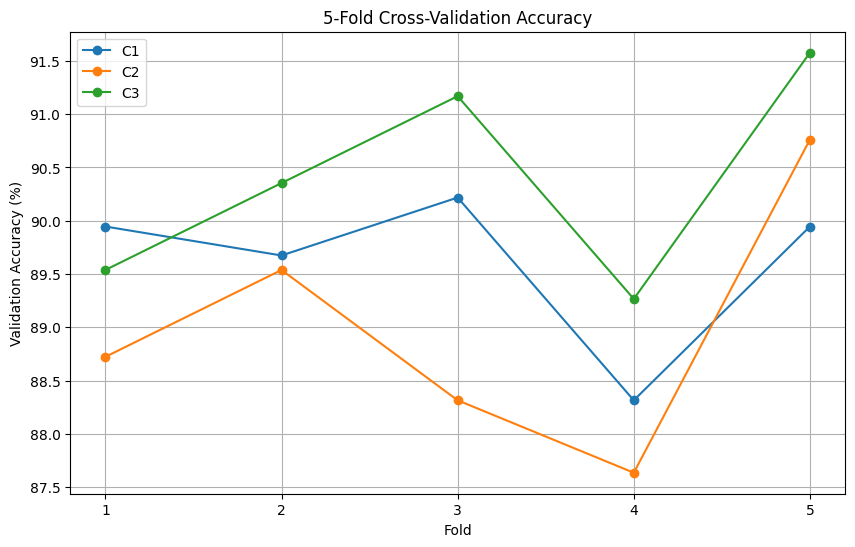

In [44]:
plt.figure(figsize=(10, 6))

for config_name, scores in cv_results.items():

    plt.plot(
        range(1, K + 1),
        scores,

        marker="o",

        label=config_name
    )

plt.xlabel(
    "Fold"
)

plt.ylabel(
    "Validation Accuracy (%)"
)

plt.title(
    "5-Fold Cross-Validation Accuracy"
)

plt.xticks(
    range(1, K + 1)
)

plt.legend()
plt.grid(True)

plt.show()

In [45]:
best_config_name = (
    cv_results_df.loc[
        cv_results_df[
            "Mean Accuracy (%)"
        ].idxmax(),

        "Configuration"
    ]
)


print(
    "Best Configuration:",
    best_config_name
)


best_config = cv_configurations[
    best_config_name
]


print("\nBest Configuration Parameters:")

for key, value in best_config.items():

    print(
        key,
        ":",
        value
    )

Best Configuration: C3

Best Configuration Parameters:
initializer : he_normal
dropout_rate : 0.2
l2_strength : 0.0001
use_batch_norm : True
optimizer : adam
learning_rate : 0.0001


In [46]:
final_train_ds = create_dataset(
    trainval_paths,
    trainval_labels,
    batch_size=BASE_BATCH_SIZE,
    shuffle=True
)


final_model = create_model(
    initializer=best_config[
        "initializer"
    ],

    dropout_rate=best_config[
        "dropout_rate"
    ],

    l2_strength=best_config[
        "l2_strength"
    ],

    use_batch_norm=best_config[
        "use_batch_norm"
    ],

    hidden_units=256,
    base_trainable=False
)


final_model = compile_model(
    final_model,

    optimizer_name=best_config[
        "optimizer"
    ],

    learning_rate=best_config[
        "learning_rate"
    ]
)


FINAL_EPOCHS = 10


start_time = time.time()


final_history = final_model.fit(
    final_train_ds,

    validation_data=val_base,

    epochs=FINAL_EPOCHS,

    verbose=1
)


final_training_time = (
    time.time() - start_time
)

Epoch 1/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 30s 90ms/step - accuracy: 0.4353 - loss: 2.3449 - val_accuracy: 0.8247 - val_loss: 1.0059
Epoch 2/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.8087 - loss: 0.9698 - val_accuracy: 0.9239 - val_loss: 0.5099
Epoch 3/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.8777 - loss: 0.6373 - val_accuracy: 0.9361 - val_loss: 0.3714
Epoch 4/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.9057 - loss: 0.5009 - val_accuracy: 0.9443 - val_loss: 0.2950
Epoch 5/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.9242 - loss: 0.4114 - val_accuracy: 0.9647 - val_loss: 0.2442
Epoch 6/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.9356 - loss: 0.3540 - val_accuracy: 0.9769 - val_loss: 0.2077
Epoch 7/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.9484 - loss: 0.3148 - val_accuracy: 0.9823 - val_loss: 0.1807
Epoch 8/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.9598 - loss: 0.2695 - 

In [47]:
test_loss, test_accuracy = final_model.evaluate(
    test_base,
    verbose=1
)


print(
    "Test Loss:",
    test_loss
)

print(
    "Test Accuracy (%):",
    test_accuracy * 100
)

print(
    "Training Time (seconds):",
    final_training_time
)

print(
    "Number of Parameters:",
    final_model.count_params()
)

230/230 ━━━━━━━━━━━━━━━━━━━━ 25s 108ms/step - accuracy: 0.8992 - loss: 0.3890
Test Loss: 0.3889588713645935
Test Accuracy (%): 89.91550803184509
Training Time (seconds): 158.54263162612915
Number of Parameters: 2596453


In [48]:
test_probabilities = final_model.predict(
    test_base,
    verbose=1
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1
)

230/230 ━━━━━━━━━━━━━━━━━━━━ 22s 72ms/step


In [49]:
precision = precision_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)


print(
    "Precision:",
    precision
)

print(
    "Recall:",
    recall
)

print(
    "F1-Score:",
    f1
)

Precision: 0.899928384126961
Recall: 0.899155083128918
F1-Score: 0.8981598262467421


In [50]:
best_cv_row = cv_results_df.loc[
    cv_results_df[
        "Configuration"
    ] == best_config_name
].iloc[0]


final_results = pd.DataFrame(
    {
        "Metric": [
            "Mean CV Accuracy (%)",
            "CV Standard Deviation",
            "Test Accuracy (%)",
            "Precision",
            "Recall",
            "F1-Score",
            "Training Time (s)",
            "Number of Parameters"
        ],

        "Value": [
            best_cv_row[
                "Mean Accuracy (%)"
            ],

            best_cv_row[
                "SD"
            ],

            test_accuracy * 100,

            precision,

            recall,

            f1,

            final_training_time,

            final_model.count_params()
        ]
    }
)


final_results

,Metric,Value
0,Mean CV Accuracy (%),9.038044e+01
1,CV Standard Deviation,1.000281e+00
2,Test Accuracy (%),8.991551e+01
3,Precision,8.999284e-01
4,Recall,8.991551e-01
5,F1-Score,8.981598e-01
6,Training Time (s),1.585426e+02
7,Number of Parameters,2.596453e+06


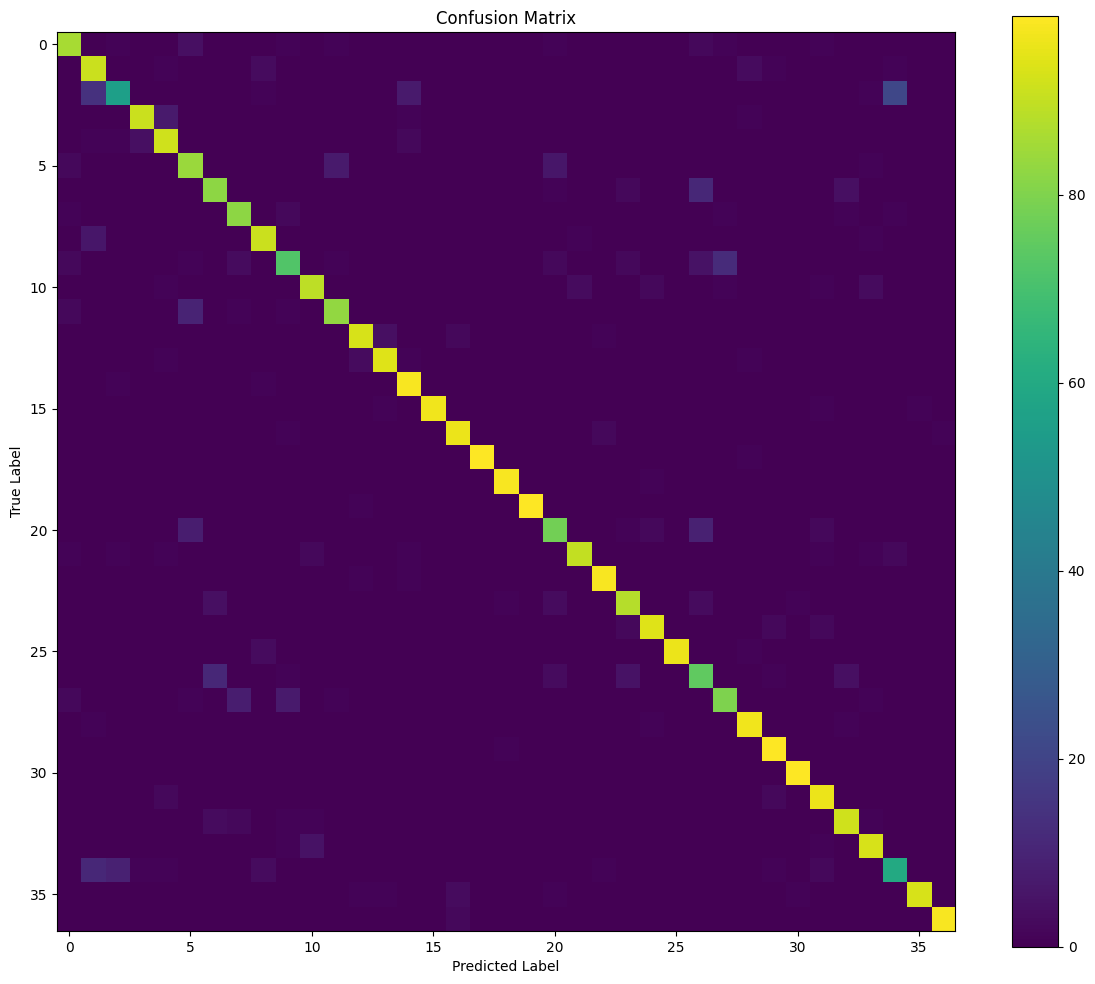

In [51]:
cm = confusion_matrix(
    test_labels,
    test_predictions
)

plt.figure(
    figsize=(12, 10)
)

plt.imshow(
    cm
)

plt.colorbar()

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.title(
    "Confusion Matrix"
)

plt.tight_layout()

plt.show()

In [52]:
print(
    classification_report(
        test_labels,

        test_predictions,

        target_names=class_names,

        zero_division=0
    )
)

                            precision    recall  f1-score   support

                Abyssinian       0.90      0.88      0.89        98
          american_bulldog       0.73      0.91      0.81       100
 american_pit_bull_terrier       0.81      0.56      0.66       100
              basset_hound       0.95      0.91      0.93       100
                    beagle       0.87      0.92      0.89       100
                    Bengal       0.78      0.84      0.81       100
                    Birman       0.82      0.82      0.82       100
                    Bombay       0.85      0.93      0.89        88
                     boxer       0.89      0.92      0.91        99
         British_Shorthair       0.83      0.72      0.77       100
                 chihuahua       0.92      0.89      0.90       100
              Egyptian_Mau       0.89      0.86      0.87        97
    english_cocker_spaniel       0.94      0.93      0.93       100
            english_setter       0.94      0.94

Correct predictions: 3299
Incorrect predictions: 370


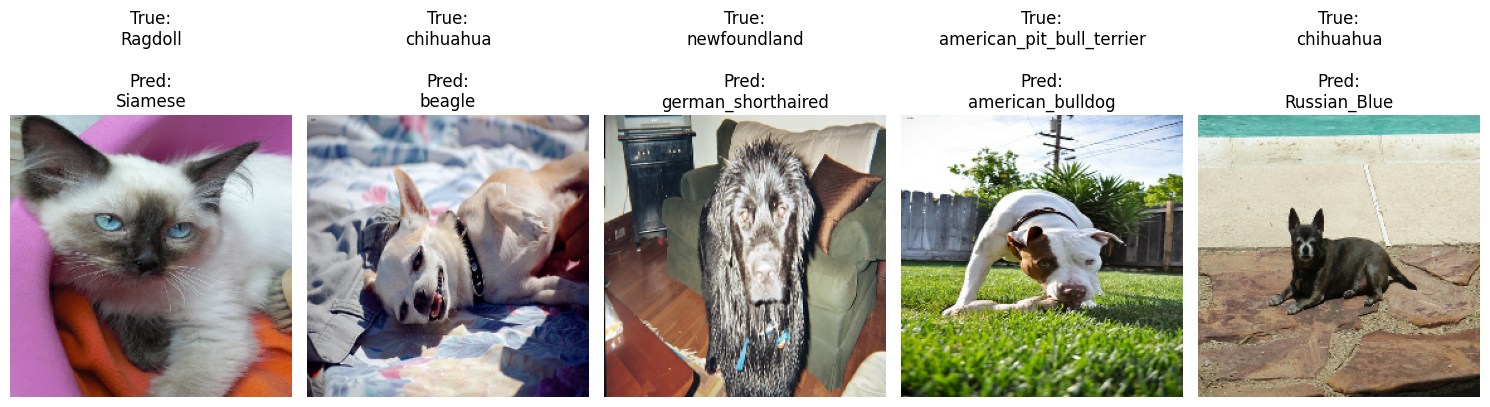

In [53]:
correct_indices = np.where(
    test_predictions == test_labels
)[0]

incorrect_indices = np.where(
    test_predictions != test_labels
)[0]


print(
    "Correct predictions:",
    len(correct_indices)
)

print(
    "Incorrect predictions:",
    len(incorrect_indices)
)


rng = np.random.default_rng(SEED)

num_examples = min(
    5,
    len(incorrect_indices)
)

selected_incorrect = rng.choice(
    incorrect_indices,

    size=num_examples,

    replace=False
)


plt.figure(
    figsize=(15, 8)
)


for i, index in enumerate(
    selected_incorrect
):

    image = tf.io.read_file(
        test_paths[index]
    )

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )


    plt.subplot(
        1,
        num_examples,
        i + 1
    )

    plt.imshow(
        image.numpy().astype(
            "uint8"
        )
    )


    true_name = class_names[
        test_labels[index]
    ]

    predicted_name = class_names[
        test_predictions[index]
    ]


    plt.title(
        f"True:\n{true_name}\n\nPred:\n{predicted_name}"
    )

    plt.axis(
        "off"
    )


plt.tight_layout()

plt.show()

In [54]:
best_init = initialization_results_df.loc[
    initialization_results_df[
        "Best Validation Accuracy (%)"
    ].idxmax(),

    "Initialization"
]


best_regularization = max(
    regularization_histories,

    key=lambda x: max(
        regularization_histories[
            x
        ].history[
            "val_accuracy"
        ]
    )
)


best_optimizer = optimizer_results_df.loc[
    optimizer_results_df[
        "Best Val Accuracy (%)"
    ].idxmax(),

    "Optimizer"
]


final_comparison = pd.DataFrame(
    {
        "Configuration": [
            "Best Initialization",
            "Best Regularization",
            "Best Optimizer",
            "Best Hyperparameters",
            "Final Model"
        ],

        "Result": [
            best_init,

            best_regularization,

            best_optimizer,

            best_config_name,

            "Selected Final Model"
        ],

        "CV Accuracy": [
            "-",
            "-",
            "-",

            (
                str(
                    round(
                        best_cv_row[
                            "Mean Accuracy (%)"
                        ],
                        2
                    )
                )

                + " ± "

                + str(
                    round(
                        best_cv_row[
                            "SD"
                        ],
                        2
                    )
                )
            ),

            round(
                test_accuracy * 100,
                2
            )
        ]
    }
)


final_comparison

,Configuration,Result,CV Accuracy
0,Best Initialization,He,-
1,Best Regularization,Batch Normalization,-
2,Best Optimizer,Adam,-
3,Best Hyperparameters,C3,90.38 ± 1.0
4,Final Model,Selected Final Model,89.92


In [55]:
print("=" * 70)
print("FINAL ASSIGNMENT SUMMARY")
print("=" * 70)

print(
    "Dataset:",
    "Oxford-IIIT Pet Dataset"
)

print(
    "Number of Classes:",
    NUM_CLASSES
)

print(
    "Best Initialization:",
    best_init
)

print(
    "Best Regularization:",
    best_regularization
)

print(
    "Best Optimizer:",
    best_optimizer
)

print(
    "Best Cross-Validation Configuration:",
    best_config_name
)

print(
    "Mean CV Accuracy:",
    round(
        best_cv_row[
            "Mean Accuracy (%)"
        ],
        2
    )
)

print(
    "CV Standard Deviation:",
    round(
        best_cv_row[
            "SD"
        ],
        2
    )
)

print(
    "Final Test Accuracy:",
    round(
        test_accuracy * 100,
        2
    )
)

print(
    "Precision:",
    round(
        precision,
        4
    )
)

print(
    "Recall:",
    round(
        recall,
        4
    )
)

print(
    "F1-Score:",
    round(
        f1,
        4
    )
)

print(
    "Training Time:",
    round(
        final_training_time,
        2
    ),
    "seconds"
)

print(
    "Number of Parameters:",
    final_model.count_params()
)

FINAL ASSIGNMENT SUMMARY
Dataset: Oxford-IIIT Pet Dataset
Number of Classes: 37
Best Initialization: He
Best Regularization: Batch Normalization
Best Optimizer: Adam
Best Cross-Validation Configuration: C3
Mean CV Accuracy: 90.38
CV Standard Deviation: 1.0
Final Test Accuracy: 89.92
Precision: 0.8999
Recall: 0.8992
F1-Score: 0.8982
Training Time: 158.54 seconds
Number of Parameters: 2596453
